In [1]:
import parselmouth
import matplotlib.pyplot as plt
from audiochains.streams import StreamFromFile
from audiochains.block_methods import UnpackRawInFloat32
import numpy as np
import time as t  # Переименование модуля time

In [2]:
def plot_intensity(audio_file, praat_file, blocksize=512):
    """
    Функция для построения графиков интенсивности из звукового файла и данных из Praat.

    :param audio_file: Путь к звуковому файлу.
    :param praat_file: Путь к файлу с данными интенсивности из Praat.
    :param blocksize: Размер блока для обработки звука.
    """
    times = []
    intensities = []

    # Чтение значений интенсивности из praat_file
    praat_times = []
    praat_intensities = []
    try:
        with open(praat_file, 'r') as f:
            next(f)  # Пропускаем заголовок
            for line in f:
                time, intensity = line.strip().split()
                praat_times.append(float(time))
                praat_intensities.append(float(intensity))
    except Exception as e:
        print(f"Ошибка при чтении файла {praat_file}: {e}")

    # Обработка звукового файла
    with StreamFromFile(filename=audio_file, blocksize=blocksize) as stream:
        print(f"Частота дискретизации: {stream.samplerate} Гц")
        stream.set_methods(UnpackRawInFloat32())

        current_time = 0
        for i in range(stream.get_iterations()):
            try:
                raw_data = stream.read(blocksize)
                if not raw_data:
                    continue

                signal = stream.chain_of_methods(raw_data)
                sound = parselmouth.Sound(values=signal, sampling_frequency=stream.samplerate)

                # Вычисляем интенсивность
                intensity = sound.to_intensity()
                frame_times = intensity.xs()
                frame_values = intensity.values.T.flatten()

                times.extend(current_time + frame_times)
                intensities.extend(frame_values)

                current_time += blocksize / stream.samplerate

            except Exception as err:
                print(f"Ошибка при обработке блока {i}: {err}")

    # Построение графиков
    plt.figure(figsize=(12, 8))

    if times and intensities:
        plt.plot(times, intensities, label="Интенсивность (из звукового файла)", color="blue")

    if praat_times and praat_intensities:
        plt.plot(praat_times, praat_intensities, label="Интенсивность (Praat)", color="red", linestyle="--")

    plt.xlabel("Время (с)")
    plt.ylabel("Интенсивность (дБ)")
    plt.title("График интенсивности")
    plt.legend()
    plt.grid()
    plt.show()

Частота дискретизации: 16000 Гц


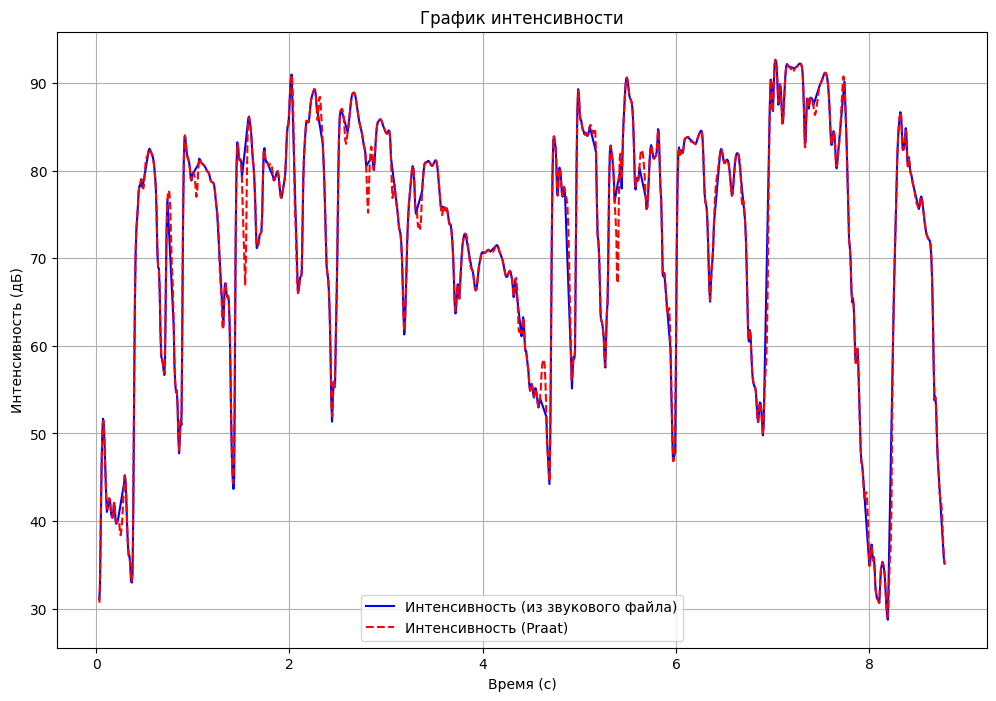

In [3]:
plot_intensity(
    audio_file='silero_vad/files/test1nonoise.wav',
    praat_file='silero_vad/files/inttest1nonoise.txt',
    blocksize=4112
)
